True T1       = 100.000 us
Fitted T1     = 100.149 us
1-sigma error = 0.814 us
95% CI        = +/- 1.657 us
Fitted A, B   = -2.0052, 1.0028  (expect A~-2, B~+1)

Saved plot to step3_t1_inversion_recovery.png


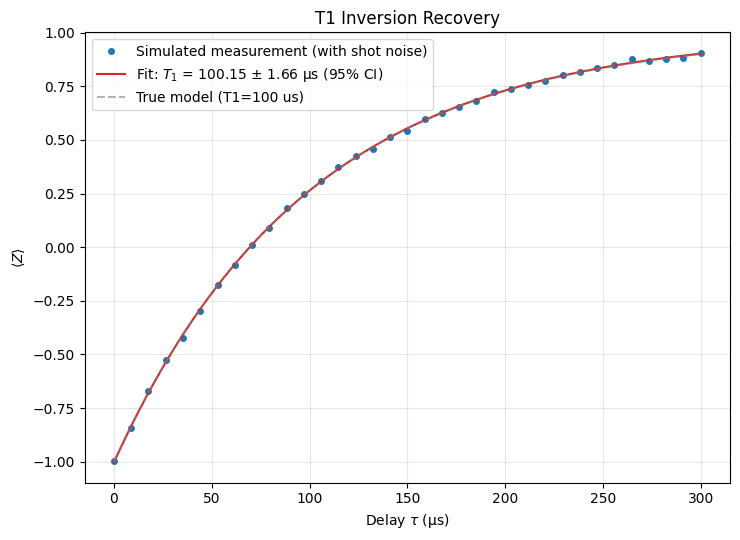

In [8]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from qiskit_dynamics import Solver

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
sigma_minus = np.array([[0, 1], [0, 0]], dtype=complex)


def bloch_z(rho):
    return np.real(np.trace(rho @ sz))



# 1. Same solver setup

wq = 2 * np.pi * 5e9
T1_true = 100e-6
T2_true = 80e-6
Tphi_true = 1 / (1 / T2_true - 1 / (2 * T1_true))

L1 = np.sqrt(1 / T1_true) * sigma_minus
L2 = np.sqrt(1 / Tphi_true) * sz
static_hamiltonian = 0.5 * wq * sz

solver = Solver(
    static_hamiltonian=static_hamiltonian,
    static_dissipators=[L1, L2],
    rotating_frame=static_hamiltonian,
)


# 2. Inversion-recovery sweep

# Step 1: pi-pulse prepares |1><1|
rho_after_pi = np.array([[0, 0], [0, 1]], dtype=complex)

n_points = 35
tau_list = np.linspace(0, 3 * T1_true, n_points)

z_data = []
for tau in tau_list:
    if tau == 0:
        z_data.append(bloch_z(rho_after_pi))
        continue
    result = solver.solve(t_span=[0, tau], y0=rho_after_pi, t_eval=[tau], method="RK45")
    z_data.append(bloch_z(result.y[-1]))
z_data = np.array(z_data)

# Add small realistic measurement
rng = np.random.default_rng(42)
shot_noise_std = 0.01
z_noisy = z_data + rng.normal(0, shot_noise_std, size=z_data.shape)

# 3. Fit  <Z>(tau) = A*exp(-tau/T1) + B

def model(tau, A, T1, B):
    return A * np.exp(-tau / T1) + B

p0 = [-2.0, 80e-6, 1.0]  # initial guesses
popt, pcov = curve_fit(model, tau_list, z_noisy, p0=p0, maxfev=10000)
A_fit, T1_fit, B_fit = popt
perr = np.sqrt(np.diag(pcov))  # 1-sigma standard errors
T1_sigma = perr[1]

from scipy.stats import t as t_dist
dof = max(0, len(tau_list) - len(popt))
t_val = t_dist.ppf(0.975, dof)
T1_ci95 = t_val * T1_sigma

print(f"True T1       = {T1_true*1e6:.3f} us")
print(f"Fitted T1     = {T1_fit*1e6:.3f} us")
print(f"1-sigma error = {T1_sigma*1e6:.3f} us")
print(f"95% CI        = +/- {T1_ci95*1e6:.3f} us")
print(f"Fitted A, B   = {A_fit:.4f}, {B_fit:.4f}  (expect A~-2, B~+1)")


# 4. Plot

tau_fine = np.linspace(0, 3 * T1_true, 300)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(tau_list * 1e6, z_noisy, 'o', ms=4, color='tab:blue', label="Simulated measurement (with shot noise)")
ax.plot(tau_fine * 1e6, model(tau_fine, *popt), '-', color='tab:red',
        label=fr"Fit: $T_1$ = {T1_fit*1e6:.2f} $\pm$ {T1_ci95*1e6:.2f} µs (95% CI)")
ax.plot(tau_fine * 1e6, model(tau_fine, -2, T1_true, 1), '--', color='gray', alpha=0.6,
        label=f"True model (T1={T1_true*1e6:.0f} us)")
ax.set_xlabel(r"Delay $\tau$ (µs)")
ax.set_ylabel(r"$\langle Z \rangle$")
ax.set_title("T1 Inversion Recovery")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("step2_lindblad_inversion_recovery.png", dpi=150)
print("\nSaved plot to step3_t1_inversion_recovery.png")


In [4]:
!pip install qiskit_dynamics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.9 MB/s eta 0:00:00
